In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.data import Data
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from rdkit import Chem
from rdkit.Chem import Draw, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
import pickle
import json
from PIL import Image
import io

print("All imports successful")

All imports successful


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool

device = torch.device('cpu')

In [4]:
# we need a modified GAT that returns attention weights
class GATModelWithAttention(nn.Module):
    def __init__(self, node_features=76, hidden=64,
                 heads=8, dropout=0.3):
        super().__init__()
        self.conv1 = GATConv(node_features, hidden,
                             heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden * heads, hidden,
                             heads=heads, dropout=dropout)
        self.conv3 = GATConv(hidden * heads, hidden,
                             heads=1, dropout=dropout,
                             add_self_loops=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        self.dropout = dropout

    def forward(self, x, edge_index, batch, 
                return_attention=False):
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        if return_attention:
            x, (edge_idx, attn) = self.conv3(
                x, edge_index, return_attention_weights=True)
        else:
            x = self.conv3(x, edge_index)
            
        x = F.elu(x)
        x = global_mean_pool(x, batch)
        out = self.classifier(x).squeeze(1)
        
        if return_attention:
            return out, edge_idx, attn
        return out

# load model
model = GATModelWithAttention().to(device)
model.load_state_dict(torch.load('../data/gat_best_model.pth',
                                  map_location=device))
model.eval()
print("Model with attention loaded successfully")

Model with attention loaded successfully


In [5]:
import pickle
import json
import numpy as np
from rdkit import Chem

# reload drugs
with open('../data/davis_drugs.txt', 'rb') as f:
    drugs = list(json.loads(
        f.read().decode('utf-8', errors='ignore')).values())

# reload graphs
with open('../data/drug_graphs.pkl', 'rb') as f:
    saved = pickle.load(f)
    graphs = saved['graphs']
    valid_indices = saved['valid_indices']

idx_map = {orig: new for new, orig in enumerate(valid_indices)}

def get_attention_weights(drug_idx):
    graph = graphs[idx_map[drug_idx]]
    
    # create batch of 1
    from torch_geometric.data import Batch
    batch = Batch.from_data_list([graph])
    
    with torch.no_grad():
        out, edge_idx, attn = model(
            batch.x, batch.edge_index, batch.batch,
            return_attention=True
        )
    
    prob = torch.sigmoid(out).item()
    
    # average attention across heads
    attn_weights = attn.squeeze().cpu().numpy()
    edge_index = edge_idx.cpu().numpy()
    
    # compute per-atom attention score
    num_atoms = graph.num_nodes
    atom_attention = np.zeros(num_atoms)
    
    for i, (src, dst) in enumerate(edge_index.T):
        if dst < num_atoms:
            atom_attention[dst] += attn_weights[i] \
                if attn_weights.ndim == 1 \
                else attn_weights[i].mean()
    
    # normalize
    if atom_attention.max() > 0:
        atom_attention = atom_attention / atom_attention.max()
    
    return prob, atom_attention, edge_index

# test on drug 0
prob, attn, _ = get_attention_weights(0)
print(f"Drug 0 binding probability: {prob:.3f}")
print(f"Atom attention scores: {attn.round(3)}")
print(f"Most attended atom index: {attn.argmax()}")

Drug 0 binding probability: 0.328
Atom attention scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1.]
Most attended atom index: 8


In [6]:
import pandas as pd

# load pairs to find high confidence predictions
df = pd.read_csv('../data/dti_pairs.csv')

# find drugs with high binding probability
print("Testing all drugs to find confident predictions...")
results = []

for i in range(len(drugs)):
    if i not in idx_map:
        continue
    prob, attn, _ = get_attention_weights(i)
    attn_std = attn.std()  # high std = unequal attention = interesting
    results.append({
        'drug_idx': i,
        'prob': prob,
        'attn_std': attn_std,
        'smiles': drugs[i]
    })

results_df = pd.DataFrame(results).sort_values(
    'prob', ascending=False)

print(f"\nTop 5 highest binding probability drugs:")
print(results_df[['drug_idx', 'prob', 'attn_std']].head())

print(f"\nTop 5 most varied attention:")
print(results_df.sort_values('attn_std', ascending=False)
      [['drug_idx', 'prob', 'attn_std']].head())

Testing all drugs to find confident predictions...

Top 5 highest binding probability drugs:
    drug_idx      prob      attn_std
56        56  0.962223  3.891668e-08
31        31  0.938888  3.951329e-08
22        22  0.831252  3.496504e-08
47        47  0.789342  3.927311e-08
58        58  0.764951  3.719712e-08

Top 5 most varied attention:
    drug_idx      prob      attn_std
28        28  0.599331  5.479104e-08
12        12  0.080772  5.416229e-08
54        54  0.002460  5.155037e-08
44        44  0.408959  4.800004e-08
49        49  0.121868  4.795149e-08


In [7]:
def get_atom_saliency(drug_idx):
    graph = graphs[idx_map[drug_idx]]
    
    from torch_geometric.data import Batch
    batch = Batch.from_data_list([graph])
    
    # enable gradients on node features
    x = batch.x.clone().requires_grad_(True)
    
    # forward pass
    out = model(x, batch.edge_index, batch.batch)
    prob = torch.sigmoid(out)
    
    # backward pass
    prob.backward()
    
    # saliency = gradient magnitude per atom
    saliency = x.grad.abs().sum(dim=1).detach().numpy()
    
    # normalize
    if saliency.max() > 0:
        saliency = saliency / saliency.max()
    
    return prob.item(), saliency

# test
prob, sal = get_atom_saliency(56)
print(f"Drug 56 binding probability: {prob:.3f}")
print(f"Saliency scores: {sal.round(3)}")
print(f"Most important atom: {sal.argmax()}")
print(f"Saliency std: {sal.std():.4f}")

Drug 56 binding probability: 0.962
Saliency scores: [0.178 1.    0.225 0.159 0.042 0.124 0.556 0.258 0.041 0.019 0.009 0.003
 0.008 0.024 0.029 0.107 0.164 0.032 0.015 0.006 0.013 0.02  0.025 0.069
 0.314 0.094 0.043 0.203 0.826 0.393 0.157 0.755 0.332 0.664 0.284]
Most important atom: 1
Saliency std: 0.2556


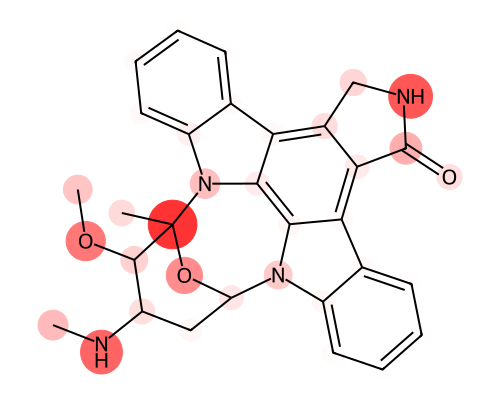

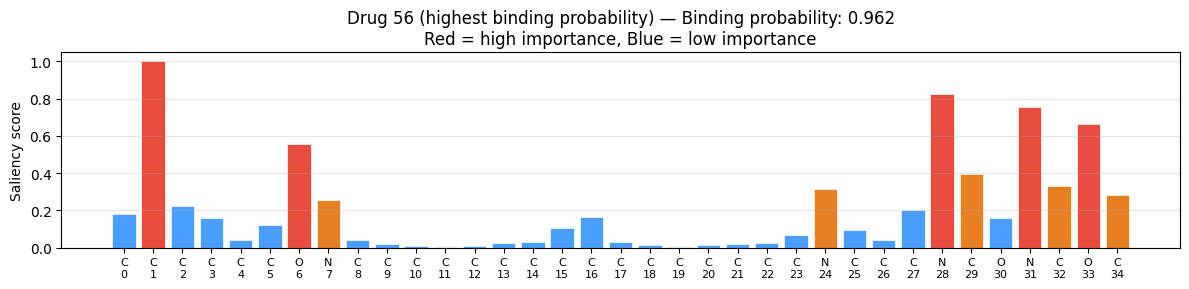

In [8]:
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display
import matplotlib.colors as mcolors

def draw_molecule_saliency(drug_idx, title=None):
    prob, saliency = get_atom_saliency(drug_idx)
    smiles = drugs[drug_idx]
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        print(f"Could not parse SMILES for drug {drug_idx}")
        return

    # create color map — low saliency = white, high = red
    atom_colors = {}
    for i in range(mol.GetNumAtoms()):
        s = float(saliency[i]) if i < len(saliency) else 0
        # interpolate white to red
        r = 1.0
        g = 1.0 - s * 0.8
        b = 1.0 - s * 0.8
        atom_colors[i] = (r, g, b)

    atom_radii = {i: 0.3 + 0.4 * float(saliency[i])
                  for i in range(mol.GetNumAtoms())
                  if i < len(saliency)}

    # draw
    drawer = rdMolDraw2D.MolDraw2DSVG(500, 400)
    drawer.drawOptions().addAtomIndices = False
    rdMolDraw2D.PrepareMolForDrawing(mol)
    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(range(mol.GetNumAtoms())),
        highlightAtomColors=atom_colors,
        highlightAtomRadii=atom_radii,
        highlightBonds=[],
        highlightBondColors={}
    )
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()

    # convert SVG to image
    from IPython.display import SVG
    display(SVG(svg))

    # also plot saliency bar chart
    fig, ax = plt.subplots(figsize=(12, 3))
    atom_symbols = [mol.GetAtomWithIdx(i).GetSymbol()
                    for i in range(mol.GetNumAtoms())]
    colors = ['#e74c3c' if s > 0.5 else
              '#e67e22' if s > 0.25 else
              '#4a9eff'
              for s in saliency]
    bars = ax.bar(range(len(saliency)), saliency,
                  color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(saliency)))
    ax.set_xticklabels([f'{sym}\n{i}'
                        for i, sym in enumerate(atom_symbols)],
                       fontsize=8)
    ax.set_ylabel('Saliency score')
    ax.set_title(f'{title or f"Drug {drug_idx}"} — '
                 f'Binding probability: {prob:.3f}\n'
                 f'Red = high importance, Blue = low importance')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# visualize drug 56 — highest binding probability
draw_molecule_saliency(56, "Drug 56 (highest binding probability)")

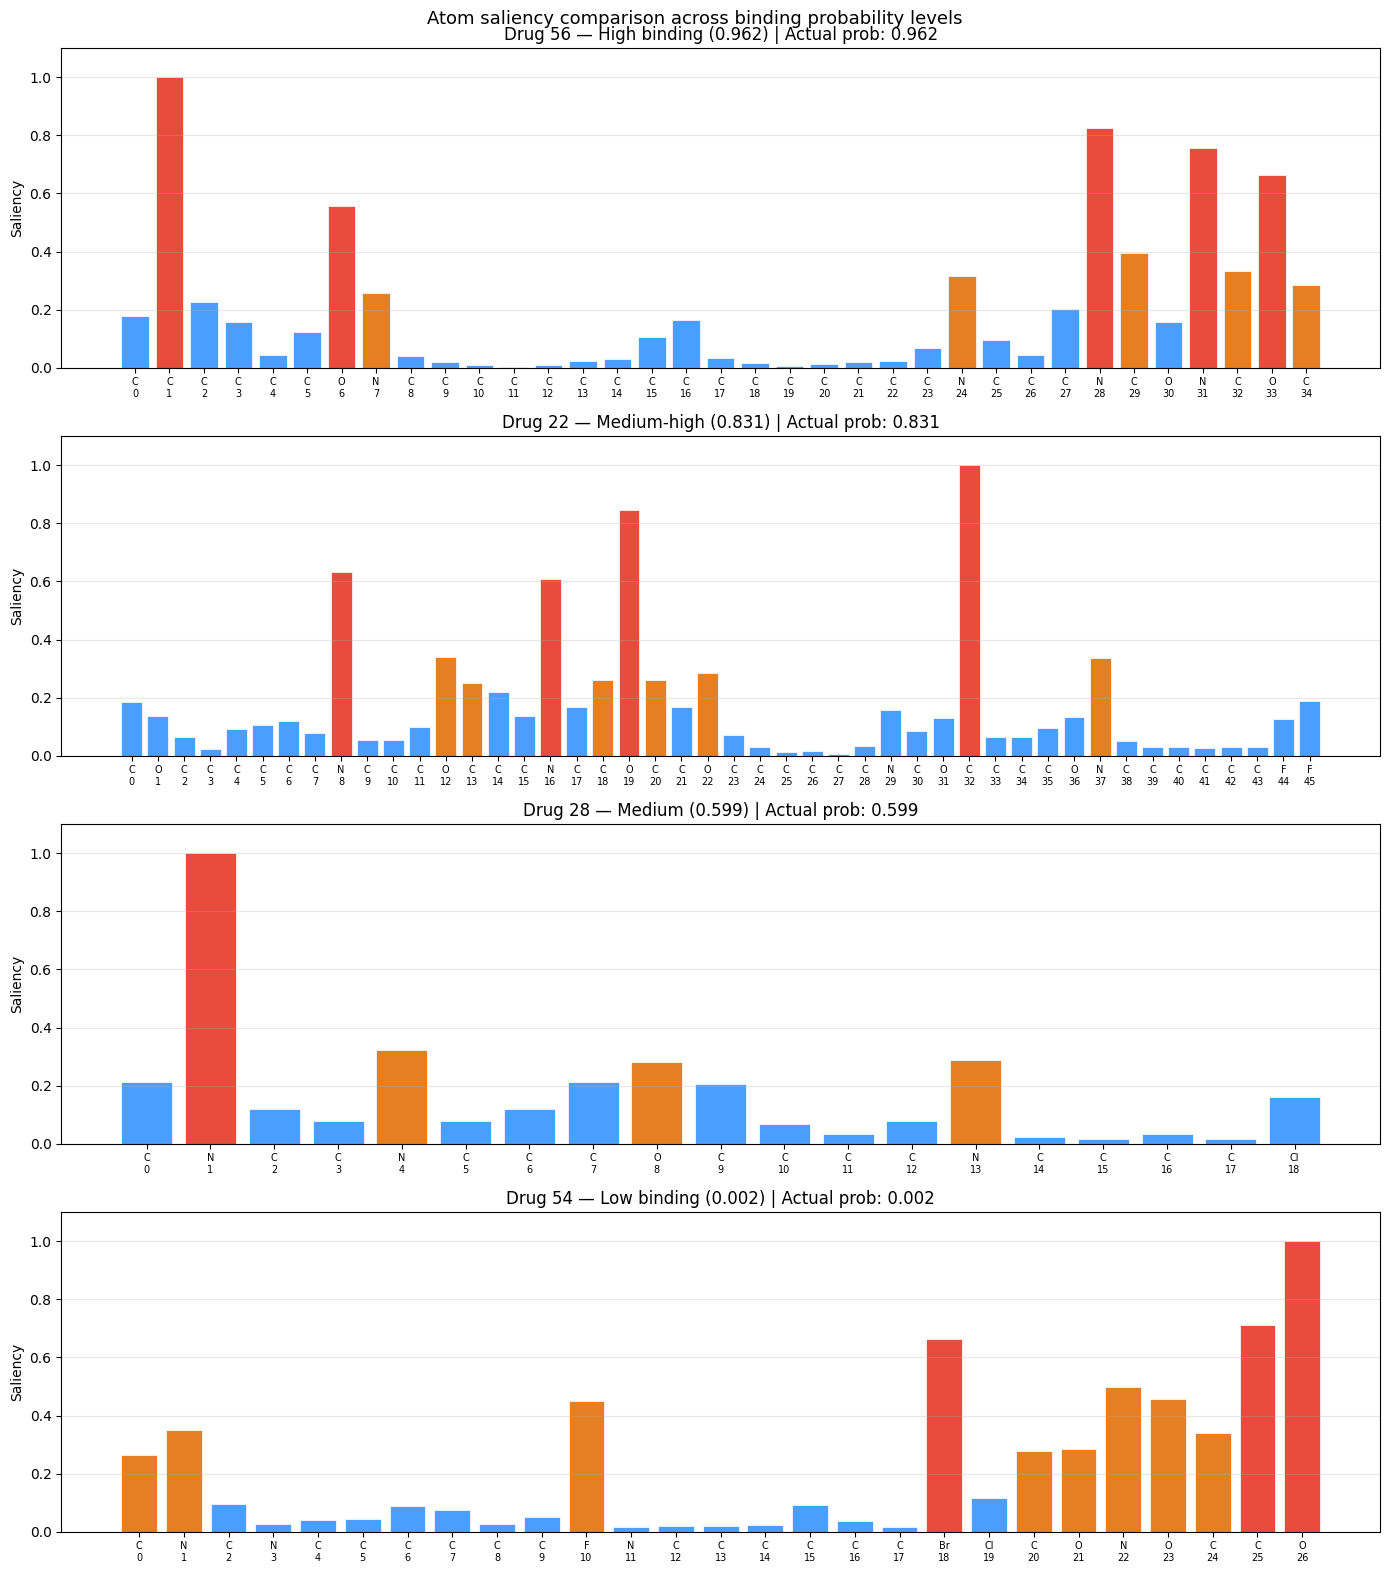

In [9]:
# compare 4 drugs — high, medium, low binding probability
selected_drugs = [
    (56, "High binding (0.962)"),
    (22, "Medium-high (0.831)"),
    (28, "Medium (0.599)"),
    (54, "Low binding (0.002)")
]

fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for ax, (drug_idx, label) in zip(axes, selected_drugs):
    prob, saliency = get_atom_saliency(drug_idx)
    mol = Chem.MolFromSmiles(drugs[drug_idx])
    atom_symbols = [mol.GetAtomWithIdx(i).GetSymbol()
                    for i in range(mol.GetNumAtoms())]
    
    colors = ['#e74c3c' if s > 0.5 else
              '#e67e22' if s > 0.25 else
              '#4a9eff'
              for s in saliency]
    
    ax.bar(range(len(saliency)), saliency,
           color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(saliency)))
    ax.set_xticklabels([f'{sym}\n{i}'
                        for i, sym in enumerate(atom_symbols)],
                       fontsize=7)
    ax.set_ylabel('Saliency')
    ax.set_title(f'Drug {drug_idx} — {label} '
                 f'| Actual prob: {prob:.3f}')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.1)

plt.suptitle('Atom saliency comparison across binding probability levels',
             fontsize=13)
plt.tight_layout()
plt.show()